# 🏠 House Price Prediction with Linear Regression
### Oasis Infobyte — Level 2, Task 1

Using the official Kaggle **House Prices: Advanced Regression Techniques** training data.

## 1. Dataset Source
Download `train.csv` from the official Kaggle competition and save it as `data/housing.csv`. The dataset uses `SalePrice` as the target and includes property size, location, rooms, age-related and quality features.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

df=pd.read_csv("data/housing.csv")
print(df.shape)
df.head()

(1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## 2. EDA — Null Check and Descriptive Statistics

In [3]:
display(df.info())
display(df.describe().T)
missing=df.isna().sum().sort_values(ascending=False)
display(missing[missing>0].head(20))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

None

,count,mean,std,min,25%,50%,75%,max
Id,1460.0,730.500000,421.610009,1.0,365.75,730.5,1095.25,1460.0
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0


PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageQual        81
GarageFinish      81
GarageType        81
GarageYrBlt       81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtCond          37
BsmtQual          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64

## 3. Target Distribution

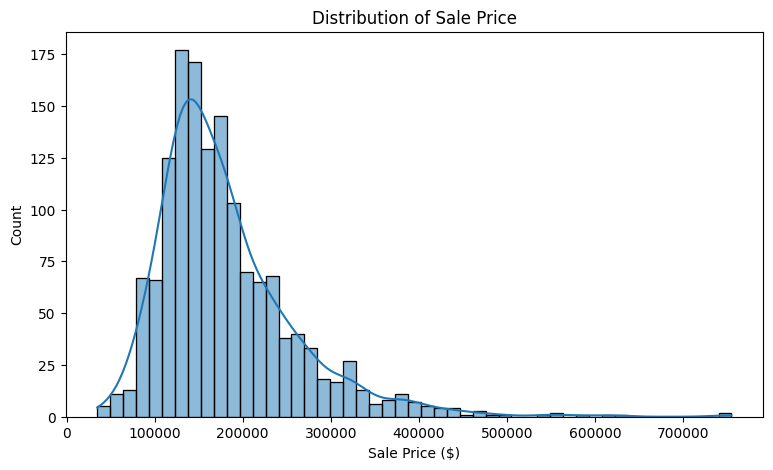

Skewness: 1.883


In [4]:
plt.figure(figsize=(9,5))
sns.histplot(df["SalePrice"], kde=True)
plt.title("Distribution of Sale Price")
plt.xlabel("Sale Price ($)")
plt.show()
print("Skewness:", round(df["SalePrice"].skew(),3))

## 4. Feature Selection Discussion
We use `GrLivArea` for area, `Neighborhood` for location, `TotRmsAbvGrd` for room count, and an engineered `HouseAge = YrSold - YearBuilt` for age. `OverallQual`, `FullBath`, `GarageCars`, and `TotalBsmtSF` add interpretable property characteristics likely to influence price.

In [5]:
df["HouseAge"]=(df["YrSold"]-df["YearBuilt"]).clip(lower=0)
NUM=["GrLivArea","TotRmsAbvGrd","FullBath","GarageCars","TotalBsmtSF","OverallQual","HouseAge"]
CAT=["Neighborhood"]
FEATURES=NUM+CAT
TARGET="SalePrice"

## 5. Correlation Heatmap

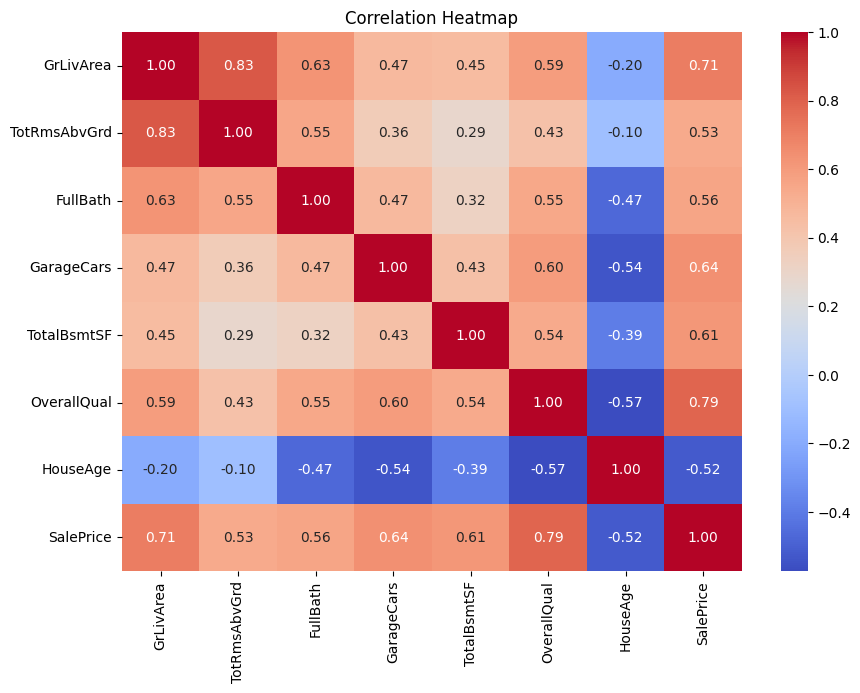

In [6]:
plt.figure(figsize=(10,7))
sns.heatmap(df[NUM+[TARGET]].corr(),annot=True,fmt=".2f",cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

## 6. Preprocessing and 80/20 Split

In [7]:
numeric=Pipeline([("imputer",SimpleImputer(strategy="median"))])
categorical=Pipeline([("imputer",SimpleImputer(strategy="most_frequent")),("onehot",OneHotEncoder(handle_unknown="ignore",sparse_output=False))])
pre=ColumnTransformer([("num",numeric,NUM),("cat",categorical,CAT)])
X=df[FEATURES]; y=df[TARGET]
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.20,random_state=42)

## 7. Train Linear Regression and Evaluate

In [8]:
linear=Pipeline([("preprocessor",pre),("model",LinearRegression())])
linear.fit(X_train,y_train)
pred=linear.predict(X_test)
mse=mean_squared_error(y_test,pred); rmse=np.sqrt(mse); r2=r2_score(y_test,pred)
print(f"MSE : {mse:,.2f}")
print(f"RMSE: {rmse:,.2f}")
print(f"R²  : {r2:.4f}")

MSE : 1,332,683,408.29
RMSE: 36,505.94
R²  : 0.8263


## 8. Actual vs Predicted

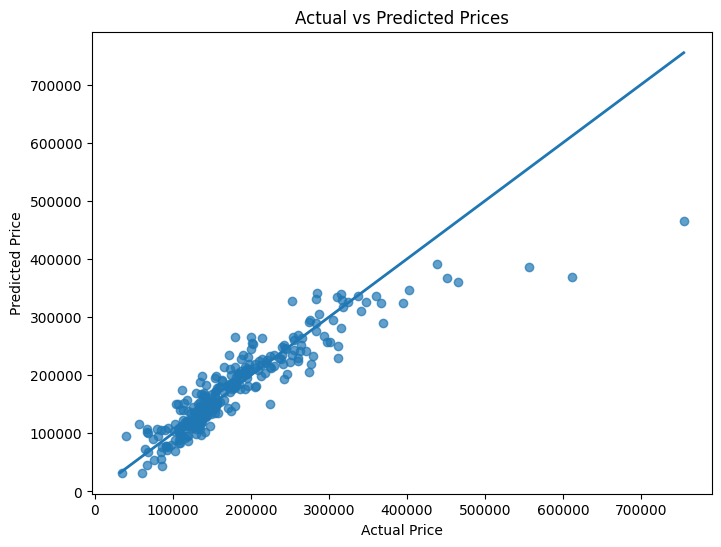

In [9]:
plt.figure(figsize=(8,6))
plt.scatter(y_test,pred,alpha=.7)
lo=min(y_test.min(),pred.min()); hi=max(y_test.max(),pred.max())
plt.plot([lo,hi],[lo,hi],linewidth=2)
plt.xlabel("Actual Price"); plt.ylabel("Predicted Price"); plt.title("Actual vs Predicted Prices"); plt.show()

## 9. Residual Plot

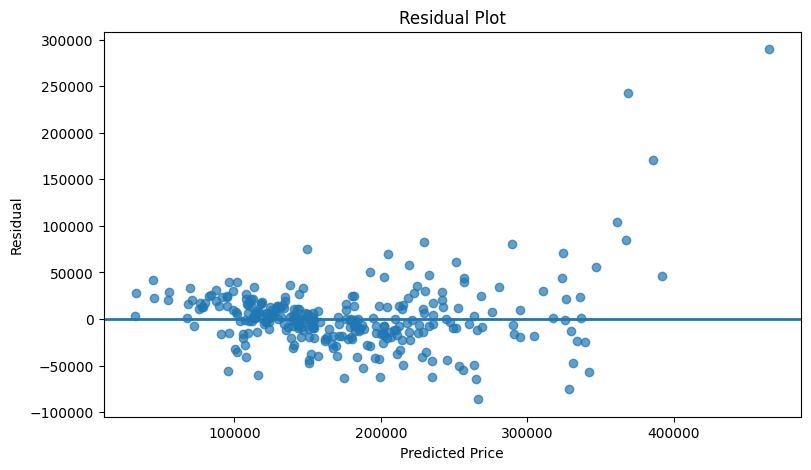

In [10]:
residuals=y_test-pred
plt.figure(figsize=(9,5))
plt.scatter(pred,residuals,alpha=.7)
plt.axhline(0,linewidth=2)
plt.xlabel("Predicted Price"); plt.ylabel("Residual"); plt.title("Residual Plot"); plt.show()

## 10. Coefficient Analysis

In [11]:
names=linear.named_steps["preprocessor"].get_feature_names_out()
coefs=linear.named_steps["model"].coef_
coef_df=pd.DataFrame({"Feature":names,"Coefficient":coefs})
coef_df["AbsoluteImpact"]=coef_df["Coefficient"].abs()
display(coef_df.sort_values("AbsoluteImpact",ascending=False).head(15))

,Feature,Coefficient,AbsoluteImpact
29,cat__Neighborhood_StoneBr,51575.791645,51575.791645
23,cat__Neighborhood_NridgHt,46902.460526,46902.460526
22,cat__Neighborhood_NoRidge,46187.314287,46187.314287
31,cat__Neighborhood_Veenker,40063.365281,40063.365281
9,cat__Neighborhood_BrDale,-38989.891000,38989.891000
8,cat__Neighborhood_Blueste,-37018.852909,37018.852909
11,cat__Neighborhood_ClearCr,26013.127378,26013.127378
7,cat__Neighborhood_Blmngtn,-23140.678373,23140.678373
20,cat__Neighborhood_NPkVill,-22684.185810,22684.185810
13,cat__Neighborhood_Crawfor,22404.799546,22404.799546


## 11. Bonus — Ridge Regression

In [12]:
ridge=Pipeline([("preprocessor",pre),("model",Ridge(alpha=10.0))])
ridge.fit(X_train,y_train)
rp=ridge.predict(X_test)
comparison=pd.DataFrame({"Model":["Linear Regression","Ridge Regression"],"MSE":[mse,mean_squared_error(y_test,rp)],"RMSE":[rmse,np.sqrt(mean_squared_error(y_test,rp))],"R2":[r2,r2_score(y_test,rp)]})
comparison

,Model,MSE,RMSE,R2
0,Linear Regression,1.332683e+09,36505.936617,0.826255
1,Ridge Regression,1.352219e+09,36772.524196,0.823708


## 12. Conclusion
Linear Regression provides a transparent baseline for house-price prediction. Area, location, quality, rooms, age, bathrooms, garage capacity and basement size provide interpretable predictors. The actual-vs-predicted plot checks prediction fit, while the residual plot checks for systematic error. Ridge Regression is included as a regularized comparison.

## References
- Kaggle — House Prices: Advanced Regression Techniques
- scikit-learn — LinearRegression
- scikit-learn — mean_squared_error
- scikit-learn — r2_score